In [1]:
adj_matrix = [
    [0, 7, 9, 0, 0, 14],
    [7, 0, 10, 15, 0, 0],
    [9, 10, 0, 11, 0, 2],
    [0, 15, 11, 0, 6, 0],
    [0, 0, 0, 6, 0, 9],
    [14, 0, 2, 0, 9, 0]
]

In [2]:
def dijkstra(adj_matrix, v):
    n = len(adj_matrix)
    d = [float('inf') for _ in range(n)]
    used = [0 for _ in range(n)]
    d[v] = 0
    while True:
        v, cur_d = None, float('inf')
        for u in range(n):
            if not used[u] and d[u] < cur_d:
                v, cur_d = u, d[u]
        if v is None or cur_d == float('inf'):
            break
        used[v] = 1
        for u in range(n):
            if adj_matrix[v][u] and d[u] > d[v] + adj_matrix[v][u]:
                d[u] = d[v] + adj_matrix[v][u]
    return [0 if dist == float('inf') else dist for dist in d]

In [3]:
dijkstra(adj_matrix, 0)

[0, 7, 9, 20, 20, 11]

In [4]:
def dijkstra_heap(adj_matrix, v):
    from heapq import heappush, heappop
    n = len(adj_matrix)
    d = [float('inf') for _ in range(n)]
    used = [0 for _ in range(n)]
    queue = [[0, v]]
    while queue:
        dist, u = heappop(queue)
        if not used[u]:
            d[u] = dist
            used[u] = 1
            for v in range(n):
                if adj_matrix[u][v] and not used[v]:
                    heappush(queue, [dist + adj_matrix[u][v], v])
    return [0 if dist == float('inf') else dist for dist in d]

In [5]:
dijkstra_heap(adj_matrix, 0)

[0, 7, 9, 20, 20, 11]

In [6]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def show_graph_with_labels(adjacency_matrix):
    adjacency_matrix = np.array(adjacency_matrix)
    rows, cols = np.where(adjacency_matrix == 1)
    edges = zip(rows.tolist(), cols.tolist())
    gr = nx.Graph()
    gr.add_edges_from(edges)
    nx.draw(gr, node_size=500)
    plt.show()
a = np.array(
        [[0, 1, 0],
         [1, 0, 0],
         [0, 0, 0]
        ]
)
show_graph_with_labels(a)

ModuleNotFoundError: No module named 'matplotlib'

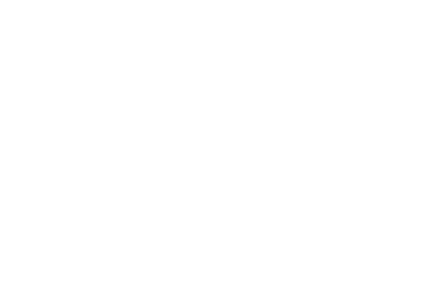

In [24]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def show_graph_with_labels(adjacency_matrix):
    adjacency_matrix = np.array(adjacency_matrix)
    rows, cols = np.where(adjacency_matrix == 1)
    edges = zip(rows.tolist(), cols.tolist())
    gr = nx.Graph()
    gr.add_edges_from(edges)
    nx.draw(gr, node_size=500)
    plt.show()

show_graph_with_labels(adj_matrix)

AttributeError: module 'matplotlib.cbook' has no attribute 'iterable'

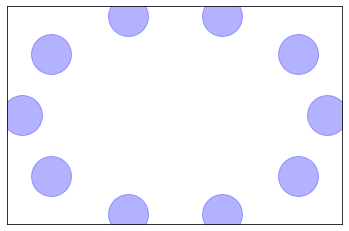

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(graph, labels=None, graph_layout='shell',
               node_size=1600, node_color='blue', node_alpha=0.3,
               node_text_size=12,
               edge_color='blue', edge_alpha=0.3, edge_tickness=1,
               edge_text_pos=0.3,
               text_font='sans-serif'):

    # create networkx graph
    G=nx.Graph()

    # add edges
    for edge in graph:
        G.add_edge(edge[0], edge[1])

    # these are different layouts for the network you may try
    # shell seems to work best
    if graph_layout == 'spring':
        graph_pos=nx.spring_layout(G)
    elif graph_layout == 'spectral':
        graph_pos=nx.spectral_layout(G)
    elif graph_layout == 'random':
        graph_pos=nx.random_layout(G)
    else:
        graph_pos=nx.shell_layout(G)

    # draw graph
    nx.draw_networkx_nodes(G,graph_pos,node_size=node_size, 
                           alpha=node_alpha, node_color=node_color)
    nx.draw_networkx_edges(G,graph_pos,width=edge_tickness,
                           alpha=edge_alpha,edge_color=edge_color)
    nx.draw_networkx_labels(G, graph_pos,font_size=node_text_size,
                            font_family=text_font)

    if labels is None:
        labels = range(len(graph))

    edge_labels = dict(zip(graph, labels))
    nx.draw_networkx_edge_labels(G, graph_pos, edge_labels=edge_labels, 
                                 label_pos=edge_text_pos)

    # show graph
    plt.show()

graph = [(0, 1), (1, 5), (1, 7), (4, 5), (4, 8), (1, 6), (3, 7), (5, 9),
         (2, 4), (0, 4), (2, 5), (3, 6), (8, 9)]

# you may name your edge labels
labels = map(chr, range(65, 65+len(graph)))
#draw_graph(graph, labels)

# if edge labels is not specified, numeric labels (0, 1, 2...) will be used
draw_graph(graph)

In [23]:
import plotly.graph_objects as go
import networkx as nx

G = nx.random_geometric_graph(10, 0.125)

In [18]:
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = G.nodes[edge[0]]['pos']
    x1, y1 = G.nodes[edge[1]]['pos']
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
for node in G.nodes():
    x, y = G.nodes[node]['pos']
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        # colorscale options
        #'Greys' | 'YlGnBu' | 'Greens' | 'YlOrRd' | 'Bluered' | 'RdBu' |
        #'Reds' | 'Blues' | 'Picnic' | 'Rainbow' | 'Portland' | 'Jet' |
        #'Hot' | 'Blackbody' | 'Earth' | 'Electric' | 'Viridis' |
        colorscale='YlGnBu',
        reversescale=True,
        color=[],
        size=10,
        colorbar=dict(
            thickness=15,
            title='Node Connections',
            xanchor='left',
            titleside='right'
        ),
        line_width=2))

In [19]:
node_adjacencies = []
node_text = []
for node, adjacencies in enumerate(G.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
    node_text.append('# of connections: '+str(len(adjacencies[1])))

node_trace.marker.color = node_adjacencies
node_trace.text = node_text

In [20]:
fig = go.Figure(data=[edge_trace, node_trace]
                )
fig.show()

In [37]:
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title='<br>Network graph made with Python',
                titlefont_size=16,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    text="Python code: <a href='https://plotly.com/ipython-notebooks/network-graphs/'> https://plotly.com/ipython-notebooks/network-graphs/</a>",
                    showarrow=False,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.show()